In [ ]:
import os
import zipfile
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from google.colab import files

# Upload the kaggle.json file from your local machine
print("Please select and upload the kaggle.json file from your desktop.")
files.upload()

# Create the necessary directory for the Kaggle API
!mkdir -p ~/.kaggle

# Move the uploaded file into the new directory
!mv kaggle.json ~/.kaggle/

# Setting the correct file permissions to secure your API key
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key uploaded and configured successfully.")

Please select and upload the kaggle.json file from your desktop.


Saving kaggle.json to kaggle.json
Kaggle API key uploaded and configured successfully.


In [ ]:
# Download and Unzip the Dataset
# You must have your kaggle.json file uploaded to Colab's file session.

# Download the dataset using the Kaggle API
!kaggle datasets download -d utkarshsaxenadn/fruits-classification

# Unzip the downloaded file
zip_file_path = 'fruits-classification.zip'
extracted_dir = 'fruits-classification-dataset'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)



Dataset URL: https://www.kaggle.com/datasets/utkarshsaxenadn/fruits-classification
License(s): CC0-1.0
  0% 0.00/84.8M [00:00<?, ?B/s]
100% 84.8M/84.8M [00:00<00:00, 1.35GB/s]


In [ ]:
# Set up Data Generators
# Define paths to your dataset directories
train_dir = os.path.join(extracted_dir, 'Fruits Classification', 'train')
validation_dir = os.path.join(extracted_dir, 'Fruits Classification', 'valid')
test_dir = os.path.join(extracted_dir, 'Fruits Classification', 'test')

# Get the number of classes from the dataset folders
num_classes = len(os.listdir(train_dir))
print(f"Number of classes: {num_classes}")


early_stop = EarlyStopping(
    monitor='val_loss',     # What to monitor (e.g., 'val_loss' or 'val_accuracy')
    patience=5,             # How many epochs to wait before stopping
    restore_best_weights=True # Restore weights from the epoch with the best value
)

Number of classes: 5


In [ ]:
# Train and Evaluate the Custom CNN Model
print("\n--- Training the Custom CNN Model ---")
target_size_cnn = (64, 64)
batch_size = 32
epochs = 100
# Create an ImageDataGenerator for the custom CNN with data augmentation
train_datagen_cnn = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
validation_datagen_cnn = ImageDataGenerator(rescale=1./255)
test_datagen_cnn = ImageDataGenerator(rescale=1./255)

train_generator_cnn = train_datagen_cnn.flow_from_directory(
    train_dir,
    target_size=target_size_cnn,
    batch_size=batch_size,
    class_mode='categorical'
)
validation_generator_cnn = validation_datagen_cnn.flow_from_directory(
    validation_dir,
    target_size=target_size_cnn,
    batch_size=batch_size,
    class_mode='categorical'
)
test_generator_cnn = test_datagen_cnn.flow_from_directory(
    test_dir,
    target_size=target_size_cnn,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Build and Compile the Custom CNN Model



model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()







--- Training the Custom CNN Model ---
Found 9700 images belonging to 5 classes.
Found 200 images belonging to 5 classes.
Found 100 images belonging to 5 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,456,517 (9.37 MB)

 Trainable params: 2,456,069 (9.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Train the model
history_cnn = model.fit(
    train_generator_cnn,
    epochs=epochs,
    validation_data=validation_generator_cnn,
    callbacks=[early_stop]
)

Epoch 1/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 111s 355ms/step - accuracy: 0.3880 - loss: 3.0820 - val_accuracy: 0.3350 - val_loss: 2.0285
Epoch 2/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 108s 354ms/step - accuracy: 0.5076 - loss: 1.3656 - val_accuracy: 0.6000 - val_loss: 1.0408
Epoch 3/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 108s 355ms/step - accuracy: 0.5661 - loss: 1.1116 - val_accuracy: 0.5300 - val_loss: 1.0604
Epoch 4/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 108s 356ms/step - accuracy: 0.5881 - loss: 1.0626 - val_accuracy: 0.5500 - val_loss: 1.2076
Epoch 5/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 108s 355ms/step - accuracy: 0.6168 - loss: 0.9954 - val_accuracy: 0.6250 - val_loss: 1.0018
Epoch 6/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 107s 353ms/step - accuracy: 0.6175 - loss: 0.9919 - val_accuracy: 0.5150 - val_loss: 1.2777
Epoch 7/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 111s 364ms/step - accuracy: 0.6398 - loss: 0.9316 - val_accuracy: 0.5700 - val_loss: 1.1382
Epoch 8/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 108s 355ms/step - accuracy: 

In [ ]:
# Evaluate the model on the test set
test_loss_cnn, test_acc_cnn = model.evaluate(test_generator_cnn)
print(f"Custom CNN Test Accuracy: {test_acc_cnn*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7807 - loss: 0.5451
Custom CNN Test Accuracy: 78.00%



Generating Confusion Matrix for Custom CNN...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step


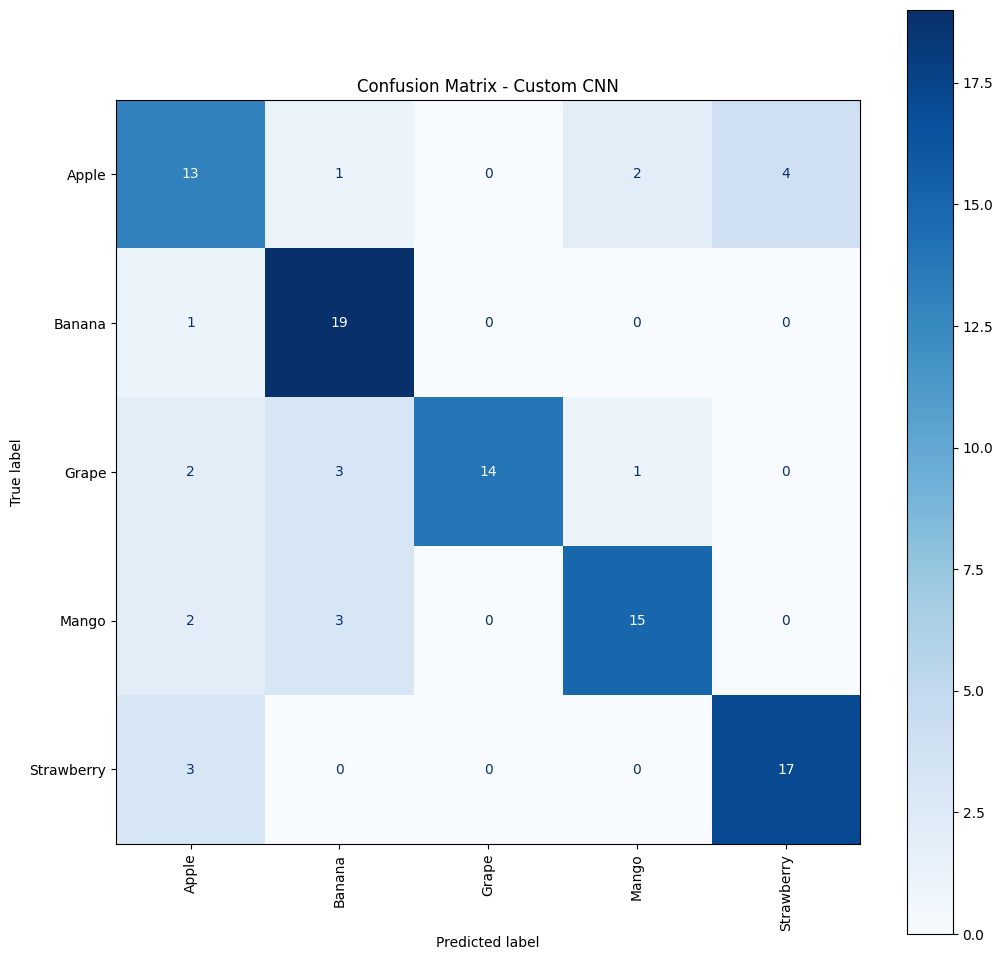

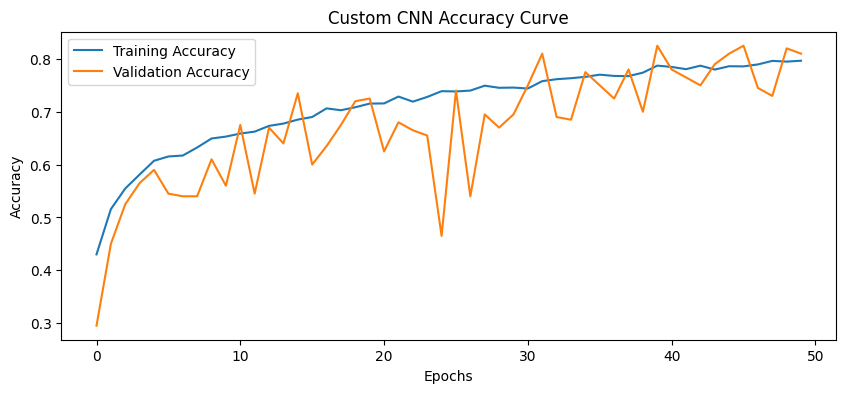

In [ ]:
# Generate and display confusion matrix for Custom CNN
print("\nGenerating Confusion Matrix for Custom CNN...")
test_generator_cnn.reset()
true_labels_cnn = test_generator_cnn.classes
predictions_cnn = model.predict(test_generator_cnn)
predicted_labels_cnn = np.argmax(predictions_cnn, axis=1)
class_names = list(test_generator_cnn.class_indices.keys())

cm_cnn = confusion_matrix(true_labels_cnn, predicted_labels_cnn)
fig, ax = plt.subplots(figsize=(12, 12))
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names)
disp_cnn.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix - Custom CNN')
plt.show()

# Plot training and validation accuracy/loss for Custom CNN
plt.figure(figsize=(10, 4))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Custom CNN Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
model.save('fruit_classifier.keras')

In [ ]:

# Load your trained model
model = tf.keras.models.load_model('fruit_classifier.keras')

# Convert to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optional: Optimize for mobile (quantization)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save to file
with open('fruit_classifier.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Model converted and saved as fruit_classifier.tflite")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saved artifact at '/tmp/tmp7c05mero'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138339766272464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138339766287632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138339507964240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138339507964432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138339507963088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138339507963280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138339507963472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138339507962704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138339507965776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138339507965968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138339507964816: 

In [ ]:
!ls -lh /content


total 144M
-rw-r--r-- 1 root root  29M Oct 14 22:56 fruit_classifier.h5
-rw-r--r-- 1 root root  29M Oct 14 22:56 fruit_classifier.keras
-rw-r--r-- 1 root root 2.4M Oct 14 23:00 fruit_classifier.tflite
drwxr-xr-x 3 root root 4.0K Oct 14 20:48 fruits-classification-dataset
-rw-r--r-- 1 root root  85M Apr  9  2023 fruits-classification.zip
drwxr-xr-x 1 root root 4.0K Oct 13 13:43 sample_data


In [ ]:
from google.colab import files
files.download('fruit_classifier.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

 # --- Part B: Train and Evaluate the Pre-trained MobileNetV2 Model ---
# Clear the Keras session to free up memory
tf.keras.backend.clear_session()
print("\n--- Training the Pre-trained MobileNetV2 Model ---")
target_size_pretrained = (224, 224)
epochs = 10

# Create an ImageDataGenerator for MobileNetV2
train_datagen_pretrained = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
validation_datagen_pretrained = ImageDataGenerator(rescale=1./255)
test_datagen_pretrained = ImageDataGenerator(rescale=1./255)

train_generator_pretrained = train_datagen_pretrained.flow_from_directory(
    train_dir,
    target_size=target_size_pretrained,
    batch_size=batch_size,
    class_mode='categorical'
)
validation_generator_pretrained = validation_datagen_pretrained.flow_from_directory(
    validation_dir,
    target_size=target_size_pretrained,
    batch_size=batch_size,
    class_mode='categorical'
)
test_generator_pretrained = test_datagen_pretrained.flow_from_directory(
    test_dir,
    target_size=target_size_pretrained,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Build and Compile the Pre-trained Model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model_pretrained = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_pretrained.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_pretrained.summary()



In [ ]:
# Train the model
history_pretrained = model_pretrained.fit(
    train_generator_pretrained,
    epochs=epochs,
    validation_data=validation_generator_pretrained
)

In [ ]:
# Evaluate the model on the test set
test_loss_pretrained, test_acc_pretrained = model_pretrained.evaluate(test_generator_pretrained)
print(f"MobileNetV2 Test Accuracy: {test_acc_pretrained*100:.2f}%")


In [ ]:
# Generate and display confusion matrix for Pre-trained Model
print("\nGenerating Confusion Matrix for MobileNetV2...")
test_generator_pretrained.reset()
true_labels_pretrained = test_generator_pretrained.classes
predictions_pretrained = model_pretrained.predict(test_generator_pretrained)
predicted_labels_pretrained = np.argmax(predictions_pretrained, axis=1)

cm_pretrained = confusion_matrix(true_labels_pretrained, predicted_labels_pretrained)
fig, ax = plt.subplots(figsize=(12, 12))
disp_pretrained = ConfusionMatrixDisplay(confusion_matrix=cm_pretrained, display_labels=class_names)
disp_pretrained.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix - MobileNetV2')
plt.show()

# Plot training and validation accuracy/loss for Pre-trained Model
plt.figure(figsize=(10, 4))
plt.plot(history_pretrained.history['accuracy'], label='Training Accuracy')
plt.plot(history_pretrained.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
model = Sequential([
    # First Conv Block
    Conv2D(64, (3, 3), activation='relu', input_shape=(64, 64, 3), padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Second Conv Block
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Third Conv Block
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Fourth Conv Block
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Global Average Pooling to reduce parameters
    GlobalAveragePooling2D(),

    # Fully connected layers
    Dense(1024, activation='relu'),
    Dropout(0.5),  # Dropout to reduce overfitting

    Dense(512, activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(num_classes, activation='softmax')
])

# Compile the model with a lower learning rate for better convergence
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary of the model
model.summary()

In [ ]:
# Train the model
history_cnn = model_cnn.fit(
    train_generator_cnn,
    epochs=15,
    validation_data=validation_generator_cnn
)

In [ ]:
# Evaluate the model on the test set
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(test_generator_cnn)
print(f"Custom CNN Test Accuracy: {test_acc_cnn*100:.2f}%")

In [ ]:
# Generate and display confusion matrix for Custom CNN
print("\nGenerating Confusion Matrix for Custom CNN...")
test_generator_cnn.reset()
true_labels_cnn = test_generator_cnn.classes
predictions_cnn = model_cnn.predict(test_generator_cnn)
predicted_labels_cnn = np.argmax(predictions_cnn, axis=1)
class_names = list(test_generator_cnn.class_indices.keys())

cm_cnn = confusion_matrix(true_labels_cnn, predicted_labels_cnn)
fig, ax = plt.subplots(figsize=(12, 12))
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names)
disp_cnn.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix - Custom CNN')
plt.show()

# Plot training and validation accuracy/loss for Custom CNN
plt.figure(figsize=(10, 4))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Custom CNN Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

